In [62]:
from pydantic import BaseModel, Field

from typing import Literal, Dict, Any, Annotated, List
from operator import add
from jinja2 import Template
from IPython.display import Image, display
import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery


from langsmith import traceable, get_current_run_tree

import openai

### LangGraph

#### Query Expansion (Parallel Execution)

In [63]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    question_relevant: bool = False
    query: str = ""
    k: int = 10

### Query Expansion/ Rewriting Node

In [64]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [65]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model= QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [66]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

### Retriever Node

In [67]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=state["query"],
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [68]:
class AggregatorResponse(BaseModel):
    answer: str

In [69]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

### USer Intent Router Node

In [70]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if the users question is not relevant to the products.")

In [71]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

## Instructions

- Determine whether the question is about products, inventory, or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not related to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant: no - about store policy, not product information

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [72]:
def intent_router_conditional_edges(state: State) -> str:
    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

### Graph Construction

In [73]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

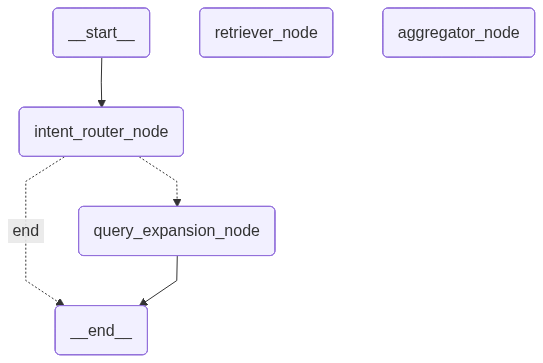

In [74]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [75]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker?"
}

In [76]:
result = graph.invoke(initial_state)

In [77]:
result

{'expanded_query': ["Kid's tablet",
  'Personal watch',
  'Laptop for wife',
  'Waterproof speaker'],
 'retrieved_context': ['- ID: B0B159KDFP, rating: 4.1, description: G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Blue 💙 【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 💙 【Kids-proof Case & Eye-protection Screen】G-TiDE\'s exclusive kids tablet case is made of impact-resistant EVA material. When your kid is playing outdoors with the tablet or

In [78]:
print(result["answer"])

Yes — based on the available products, I can suggest options in all four categories:

**Tablet for your kid**
- **G-TiDE Kids Tablet (Blue) — ID: B0B159KDFP**
  - 7-inch kids tablet with **32GB storage + 2GB RAM**
  - **5MP dual camera** and HD display
  - **Parental Control App (KLAP)** with content filtering, time limits, child lock, remote video control, and alarm settings
  - Comes with a **kids-proof EVA case**, **adjustable shoulder strap**, and **270° adjustable stand**
  - Storage can be expanded up to **128GB** with microSD card
  - Designed for children **ages 3–7**
- **Moonka Kids Tablet — ID: B0BGHBL86V**
  - 7-inch Android kids tablet with **1GB RAM + 32GB ROM**
  - Supports expansion up to **256GB**
  - Includes **pre-installed iWawa learning app** and **Google Play access**
  - Kids-friendly design with **silicone case**, **screen protector**, and **175° adjustable stand**
  - Suitable for ages **3–14**

**Watch for you**
- **SOUYIE Smart Watch — ID: B0CFLR6R3X**
  - **1

In [79]:
initial_state = {
    "initial_query": "How many times should I be walking my dog per day?"
}

In [80]:
result = graph.invoke(initial_state)

In [81]:
result

{'retrieved_context': [],
 'initial_query': 'How many times should I be walking my dog per day?',
 'answer': 'This question is not about products, inventory, or purchasing.',
 'question_relevant': False}